### 1: Завдання

Здійснити Data Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D

def data_cleaning():
    columns = [
        "age", "workclass", "fnlwgt", "education", "education-num",
        "marital-status", "occupation", "relationship", "race", "sex",
        "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
    ]

    df1 = pd.read_csv("adult/adult.data", names=columns, na_values="?", skipinitialspace=True)
    df2 = pd.read_csv("adult/adult.test", names=columns, na_values="?", skiprows=1, skipinitialspace=True)
    df2["income"] = df2["income"].str.replace(".", "", regex=False)
    df = pd.concat([df1, df2])
    print("Before data cleaning:", len(df))
    df = df.dropna()
    return df
    
df = data_cleaning()
print("After data cleaning:", len(df))
display(df.head())

Before data cleaning: 48842
After data cleaning: 45222


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 2: Завдання

Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).

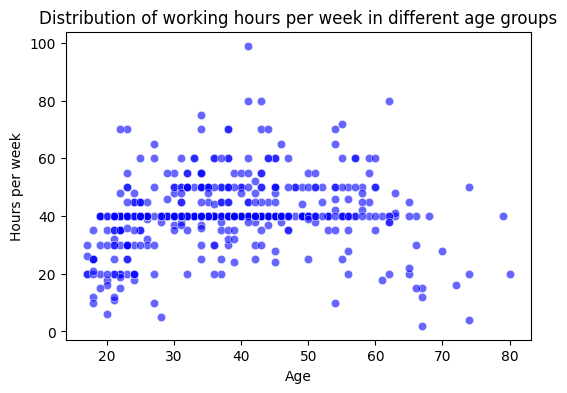

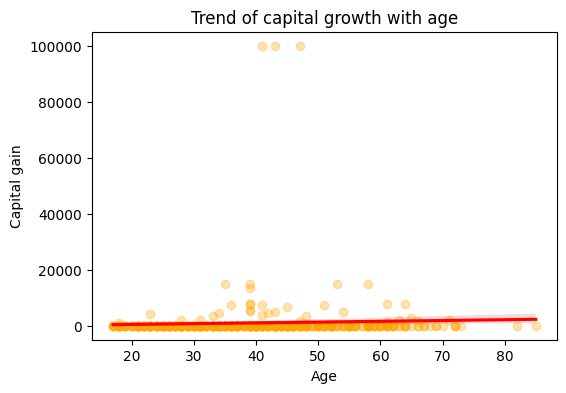

In [3]:
def dependency_graphs(df):
    plt.figure(figsize=(6,4))
    sns.scatterplot(x="age", y="hours-per-week", data=df.sample(500), alpha=0.6, color="blue")
    plt.title("Distribution of working hours per week in different age groups")
    plt.xlabel("Age")
    plt.ylabel("Hours per week")
    plt.show()
    
    plt.figure(figsize=(6,4))
    sns.regplot(x="age", y="capital-gain", data=df.sample(500), scatter_kws={"alpha":0.3, "color":"orange"}, line_kws={"color":"red"})
    plt.title("Trend of capital growth with age")
    plt.xlabel("Age")
    plt.ylabel("Capital gain")
    plt.show()
    
dependency_graphs(df)    

### 3: Завдання

Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.

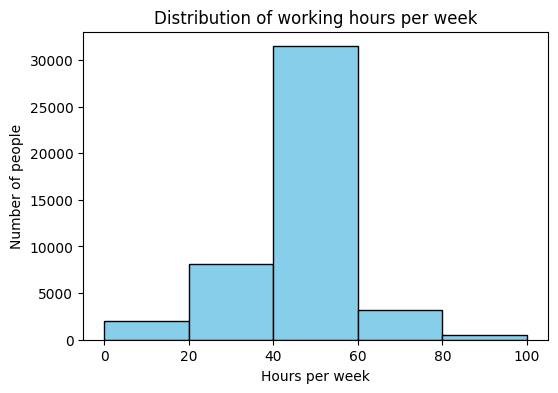

In [4]:
def attribute_histogram(df):
    attribute = "hours-per-week"
    bins = [0, 20, 40, 60, 80, 100]

    plt.figure(figsize=(6,4))
    plt.hist(df[attribute], bins=bins, color="skyblue", edgecolor="black")
    plt.title("Distribution of working hours per week")
    plt.xlabel("Hours per week")
    plt.ylabel("Number of people")
    plt.xticks(bins) 
    plt.show()

attribute_histogram(df)    

### 4: Завдання

Збудувати графіки, використовуючи приклади, наведені у medium.

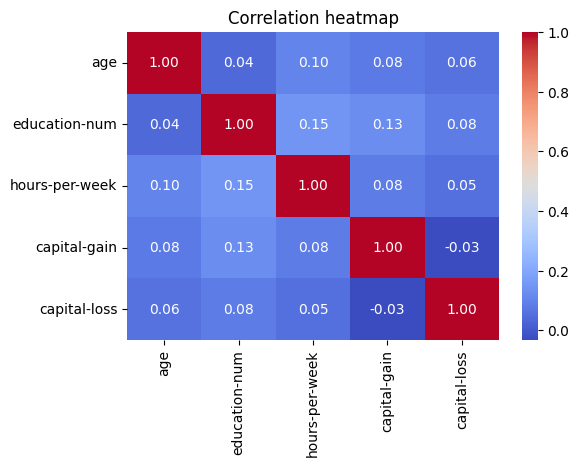

<Figure size 600x400 with 0 Axes>

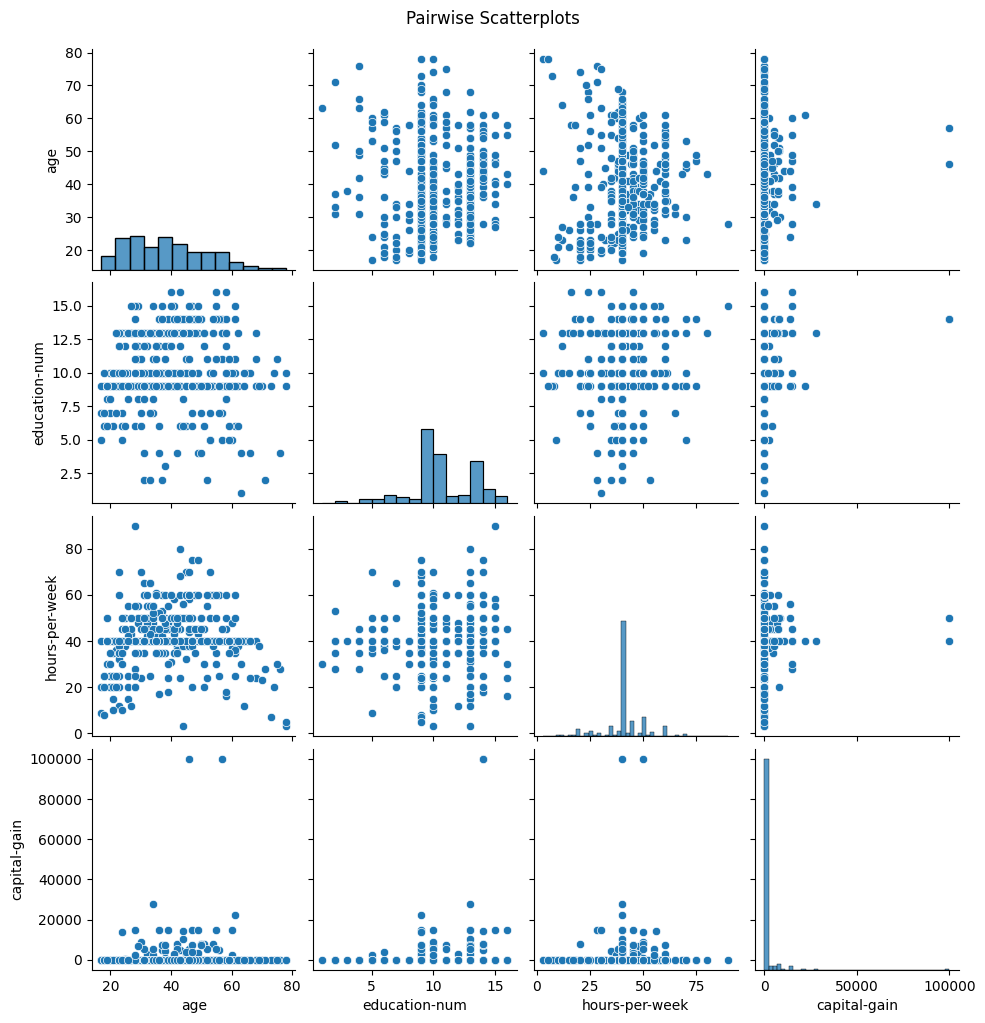

In [5]:
def medium_graphs(df):
    plt.figure(figsize=(6,4))
    corr = df[["age","education-num","hours-per-week","capital-gain","capital-loss"]].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation heatmap")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.pairplot(df.sample(500), vars=["age","education-num","hours-per-week","capital-gain"])
    plt.suptitle("Pairwise Scatterplots", y=1.02)
    plt.show()
    
medium_graphs(df)

### 5: Завдання

Побудувати інші графіки, що покажуть корисну інформацію про датасет. Загальна кількість графіків має становити 5-8.

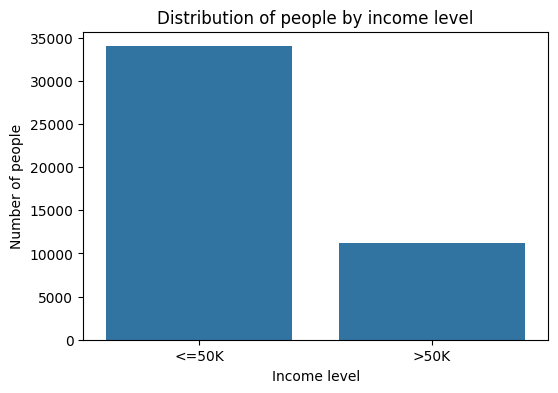

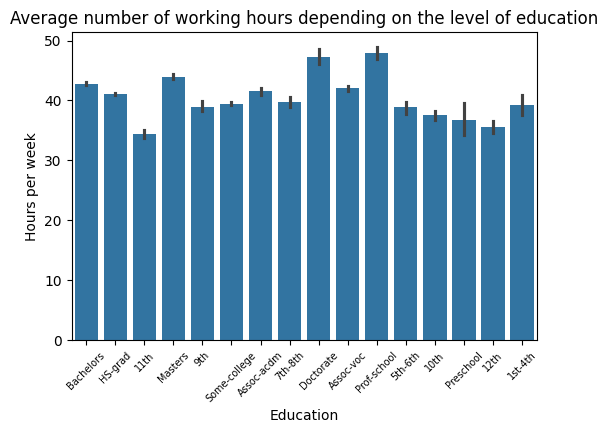

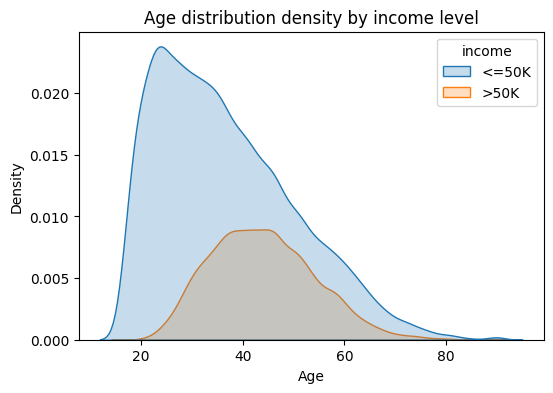

In [6]:
def effective_data(df):
    plt.figure(figsize=(6,4))
    sns.countplot(x="income", data=df)
    plt.title("Distribution of people by income level")
    plt.xlabel("Income level")
    plt.ylabel("Number of people")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.barplot(x="education", y="hours-per-week", data=df)
    plt.xticks(rotation=45, size=7)
    plt.title("Average number of working hours depending on the level of education")
    plt.xlabel("Education")
    plt.ylabel("Hours per week")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x="age", hue="income", fill=True)
    plt.title("Age distribution density by income level")
    plt.xlabel("Age")
    plt.ylabel("Density")
    plt.show()
    
effective_data(df)    